## Compare updates QR data with previous version

### Environment Setup

In [49]:
# limit CPU usage
CPU_LIMIT: int = 1

import os
os.environ["OMP_NUM_THREADS"] = str(CPU_LIMIT)
os.environ["MKL_NUM_THREADS"] = str(CPU_LIMIT)
os.environ["OPENBLAS_NUM_THREADS"] = str(CPU_LIMIT)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(CPU_LIMIT)
os.environ["NUMEXPR_NUM_THREADS"] = str(CPU_LIMIT)

# import package
import sys
import glob
import numpy as np
import pandas as pd
import xarray as xr

from tqdm import tqdm
from pprint import pprint

import matplotlib.pyplot as plt

### Load data

In [50]:
# Load previous data
with xr.open_dataset("/work/DATA/Satellite/CloudSat/CloudSat_gridded.nc", chunks={}) as prev_ds:
    prev_ds: xr.Dataset = prev_ds.sel(time=slice("2007-01-01", "2007-12-31"))
    pprint(prev_ds.coords["lon"])
    qlw_prev: xr.DataArray = prev_ds["qlw"]
    qsw_prev: xr.DataArray = prev_ds["qsw"]

# Load newly organized data
with xr.open_dataset("/data92/b11209013/CloudSat/DATA/QR_gridded.nc", chunks={}) as curr_ds:
    curr_ds: xr.Dataset = curr_ds.sel(time=slice("2007-01-01", "2007-12-31"))
    pprint(curr_ds.coords["lon"])
    qlw_curr: xr.DataArray = curr_ds["QLW"]
    qsw_curr: xr.DataArray = curr_ds["QSW"]

<xarray.DataArray 'lon' (lon: 576)> Size: 2kB
array([3.125000e-01, 9.375000e-01, 1.562500e+00, ..., 3.584375e+02,
       3.590625e+02, 3.596875e+02], dtype=float32)
Coordinates:
  * lon      (lon) float32 2kB 0.3125 0.9375 1.562 2.188 ... 358.4 359.1 359.7
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X
<xarray.DataArray 'lon' (lon: 576)> Size: 2kB
array([3.125000e-01, 9.375000e-01, 1.562500e+00, ..., 3.584375e+02,
       3.590625e+02, 3.596875e+02], dtype=float32)
Coordinates:
  * lon      (lon) float32 2kB 0.3125 0.9375 1.562 2.188 ... 358.4 359.1 359.7
Attributes:
    axis:     X


### Verification

In [51]:
# Calculate deviation
qlw_dev: xr.DataArray = qlw_curr - qlw_prev
qsw_dev: xr.DataArray = qsw_curr - qsw_prev



### Visualization

(365, 37, 360, 576)


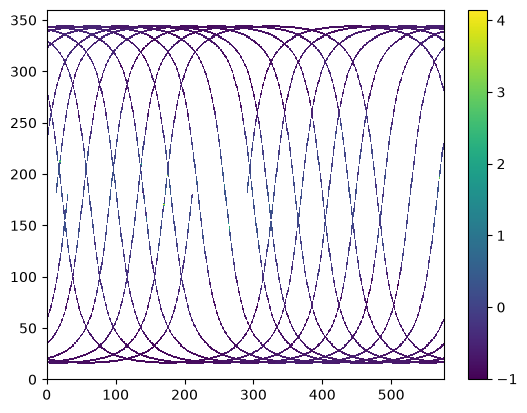

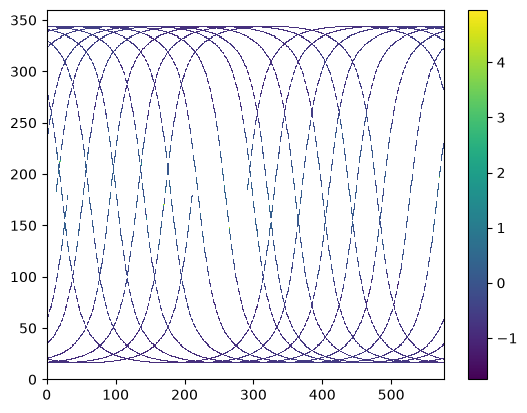

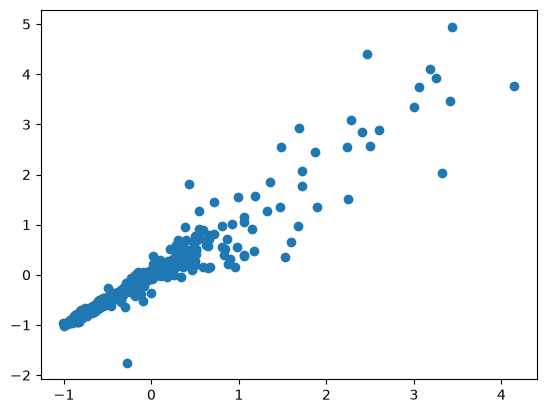

In [52]:
pprint(qlw_prev.shape)
plt.pcolormesh(qlw_prev[100, -1, ...])
plt.colorbar()

plt.show()

plt.pcolormesh(qlw_curr[100, -1, ...])
plt.colorbar()

plt.show()

plt.scatter(qlw_prev[100, -1, ...].values.flatten(), qlw_curr[100, -1, ...].values.flatten())